# Milestone 5 — M5B: clean/dirty transport pairs

Particle intersections **mark** which transport paths are affected.
`build_affected_transport_pairs` then emits **one** `AffectedTransportPair` **per
affected `path_id`** (`RaySegmentBundle.ray_ids`) — **not** one pair per
intersection event.

```text
N events on the same ray  →  still 1 AffectedTransportPair for that path
N distinct hit paths      →  N AffectedTransportPair objects
```

Multiple inclusions on one ray become multiple events / dirty intervals
**inside** that single pair (dirty intensity continues through the first
chord into the next).

Plan: [`plans/milestone_05/05_particle_plan.md`](../../plans/milestone_05/05_particle_plan.md).  
Guidelines: [`docs/milestone_05_particle_guidelines.md`](../../docs/milestone_05_particle_guidelines.md).

This notebook checks that:

1. `RaySegmentBundle` segment rows are associated with transport paths via `ray_ids`.
2. Particle intersections produce affected transport **paths** (not a pair per hit).
3. Clean/dirty pairs are created **exactly once per** particle-hit path.
4. Pairs can be visualized in geometric and path-coordinate views.

Three particle configurations:

1. **Single particle** at the mesh centroid.
2. **Two particles, lateral** — side-by-side (typically different rays → different pairs).
3. **Two particles, in-line** — along the illumination axis (some rays hit both → **one** pair with **two** red intervals).

Geometric sphere overlap is rejected by `ParticleSet.validate()`. Energy/source
correction belongs to M5C.


In [1]:
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

!pip install --quiet --no-cache-dir "{ROOT}[fem]" -c "{ROOT}/requirements.txt"

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ROOT=.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from gummybear.geometry import load_stl
from gummybear.optics import (
    OpticalMaterialConfig,
    PointLightConfig,
    SourceSamplingParams,
    generate_diffusion_mesh,
    in_object_segments_from_rays,
    make_source_ray_bundle,
    refract_ray_bundle,
)
from gummybear.particles import (
    ParticleSet,
    ParticleSphere,
    build_affected_transport_pairs,
    intersect_segments_with_particles,
)
from gummybear.paths import display_path
from gummybear_validation import notebook_tools
from gummybear_validation.helpers import assert_live_netgen_mesh
from gummybear_validation.plotting import (
    plot_affected_transport_pairs,
    plot_particle_intersections_in_mesh,
)
import gummybear_validation.milestone_05.validation as m5_validation


# Prepare scenery (M3 refraction + M4 segments)


In [3]:
STL_PATH = ROOT / "cad" / "proto_bear.stl"

surface_mesh = load_stl(STL_PATH)
# Live Netgen handle — no cache_dir (npz-ready mesh for later M5C/D).
diff_mesh = generate_diffusion_mesh(STL_PATH, target_elements=2000)
assert_live_netgen_mesh(diff_mesh)

lo, hi = diff_mesh.bounds
c = diff_mesh.bounds.mean(axis=0)

light = PointLightConfig(
    position=(c[0] + 15.0, c[1] + 15.0, hi[2] + 15.0),
    intensity=1.0,
)

source_rays = make_source_ray_bundle(
    light,
    surface_mesh.bounds,
    SourceSamplingParams(n_rays=1024, seed=0),
)

mat = OpticalMaterialConfig(
    mu_scatter=0.3,
    mu_absorption=0.1,
    n_refractive=1.33,
)

entry = refract_ray_bundle(
    surface_mesh,
    source_rays,
    n_from=1.0,
    n_to=mat.n_refractive,
)

segments = in_object_segments_from_rays(surface_mesh, entry.rays)
ray_ids = np.asarray(segments.ray_ids, dtype=int)

n_segments = getattr(segments, "n_segments", len(segments.starts))
print(f"STL={display_path(STL_PATH)}")
print(f"Found {n_segments} in-object ray segment(s).")
print(f"Distinct transport paths: {segments.n_transport_paths}")


STL=cad/proto_bear.stl
Found 852 in-object ray segment(s).
Distinct transport paths: 852


# Test particle definitions

Keep the original single-particle fixture, then define two non-overlapping
two-particle sets:

- **lateral:** offset along ±x relative to the centroid (side-by-side),
- **in-line:** offset along the point-light → centroid axis so some transport
  rays can hit both spheres.


In [4]:
particles_single = ParticleSet.from_particles([
    ParticleSphere(
        center=c,
        radius=3.0,
        mu_abs=5.0,
        mu_scat=8.0,
        particle_id="p000_mixed_phoenix",
    ),
])

lateral_offset = np.array([4.5, 0.0, 0.0], dtype=float)
particles_multi_lateral = ParticleSet.from_particles([
    ParticleSphere(
        center=c - lateral_offset,
        radius=2.5,
        mu_abs=5.0,
        mu_scat=8.0,
        particle_id="p000_left",
    ),
    ParticleSphere(
        center=c + lateral_offset,
        radius=2.5,
        mu_abs=5.0,
        mu_scat=8.0,
        particle_id="p001_right",
    ),
])

light_pos = np.asarray(light.position, dtype=float)
axis = c - light_pos
axis = axis / np.linalg.norm(axis)
inline_half_sep = 2.75  # > r+r so spheres do not overlap
particles_multi_inline = ParticleSet.from_particles([
    ParticleSphere(
        center=c - inline_half_sep * axis,
        radius=2.5,
        mu_abs=5.0,
        mu_scat=8.0,
        particle_id="p000_upstream",
    ),
    ParticleSphere(
        center=c + inline_half_sep * axis,
        radius=2.5,
        mu_abs=5.0,
        mu_scat=8.0,
        particle_id="p001_downstream",
    ),
])

assert len(particles_single) == 1
assert len(particles_multi_lateral) == 2
assert len(particles_multi_inline) == 2
assert particles_single.validate()
assert particles_multi_lateral.validate()
assert particles_multi_inline.validate()

particles = particles_single

print("Defined single-particle set:", particles_single[0].particle_id)
print("Defined lateral multi-particle set:", [p.particle_id for p in particles_multi_lateral])
print("Defined in-line multi-particle set:", [p.particle_id for p in particles_multi_inline])
print("In-line axis (light -> centroid):", axis)


Defined single-particle set: p000_mixed_phoenix
Defined lateral multi-particle set: ['p000_left', 'p001_right']
Defined in-line multi-particle set: ['p000_upstream', 'p001_downstream']
In-line axis (light -> centroid): [-0.48507125 -0.48507125 -0.72760688]


## Single-particle intersections in the transport bundle

Each event records the segment hit, entry/exit locations, and the chord of the
segment lying inside the particle.


Single-particle intersections: 113 event(s) on 113 segment(s) and 113 transport ray(s).


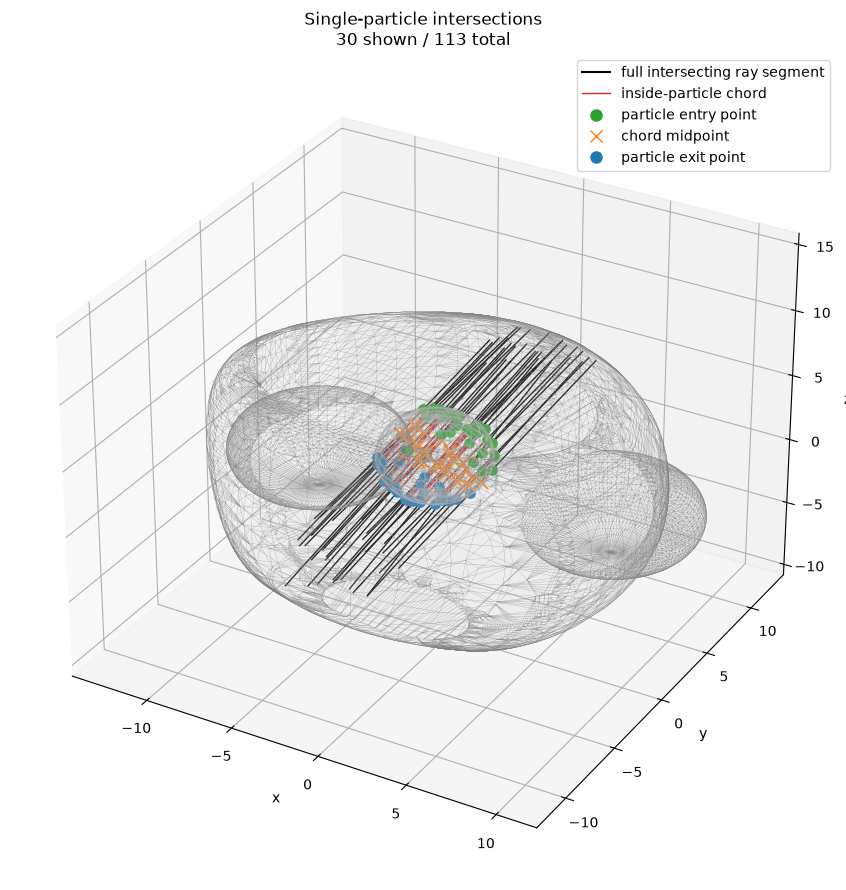

In [5]:
events = intersect_segments_with_particles(segments.starts, segments.ends, particles)
events = sorted(
    list(events),
    key=lambda ev: (int(ev.segment_index), float(ev.entry_t), int(ev.particle_index)),
)
if not events:
    raise AssertionError("No particle intersection events were found.")

event_segment_indices = np.asarray(sorted({int(ev.segment_index) for ev in events}), dtype=int)
event_path_ids = np.asarray(sorted({int(ray_ids[s]) for s in event_segment_indices}), dtype=int)

print(
    f"Single-particle intersections: {len(events)} event(s) on "
    f"{len(event_segment_indices)} segment(s) and "
    f"{len(event_path_ids)} transport ray(s)."
)

max_events_to_draw = 30
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection="3d")
plot_particle_intersections_in_mesh(
    ax,
    surface_mesh,
    particles,
    segments,
    events,
    max_events_to_draw=max_events_to_draw,
    particle_color="darkgrey",
    chord_linewidth=1.0,
    full_segment_color="black",
    full_segment_linewidth=1.0,
    title=(
        "Single-particle intersections\n"
        f"{min(max_events_to_draw, len(events))} shown / {len(events)} total"
    ),
)
plt.tight_layout()
plt.show()


# Single-particle clean/dirty transport pairs

Pytest + visualization checks that M5B constructs **one pair per** transport
path whose segments intersect the particle (pairing grain = `path_id`, not
event count).

Barcode plot: thin gray = unaffected context; thick gray = affected clean;
red = particle intervals on that path.


Single-particle transport pairs: 113 pair(s) for 113 particle-hit transport ray(s).

Milestone 5B
Test executed: test_affected_pair_indices_match_intersection_events()

pytest:
../../venv/lib/python3.12/site-packages/gummybear_validation/milestone_05/validation.py . [100%]
============================== 1 passed in 0.66s ===============================

Test proves: Clean/particle-altered transport pairs are constructed exactly for rays with
             particle-hit segments, as verified by explicit particle-intersection events.


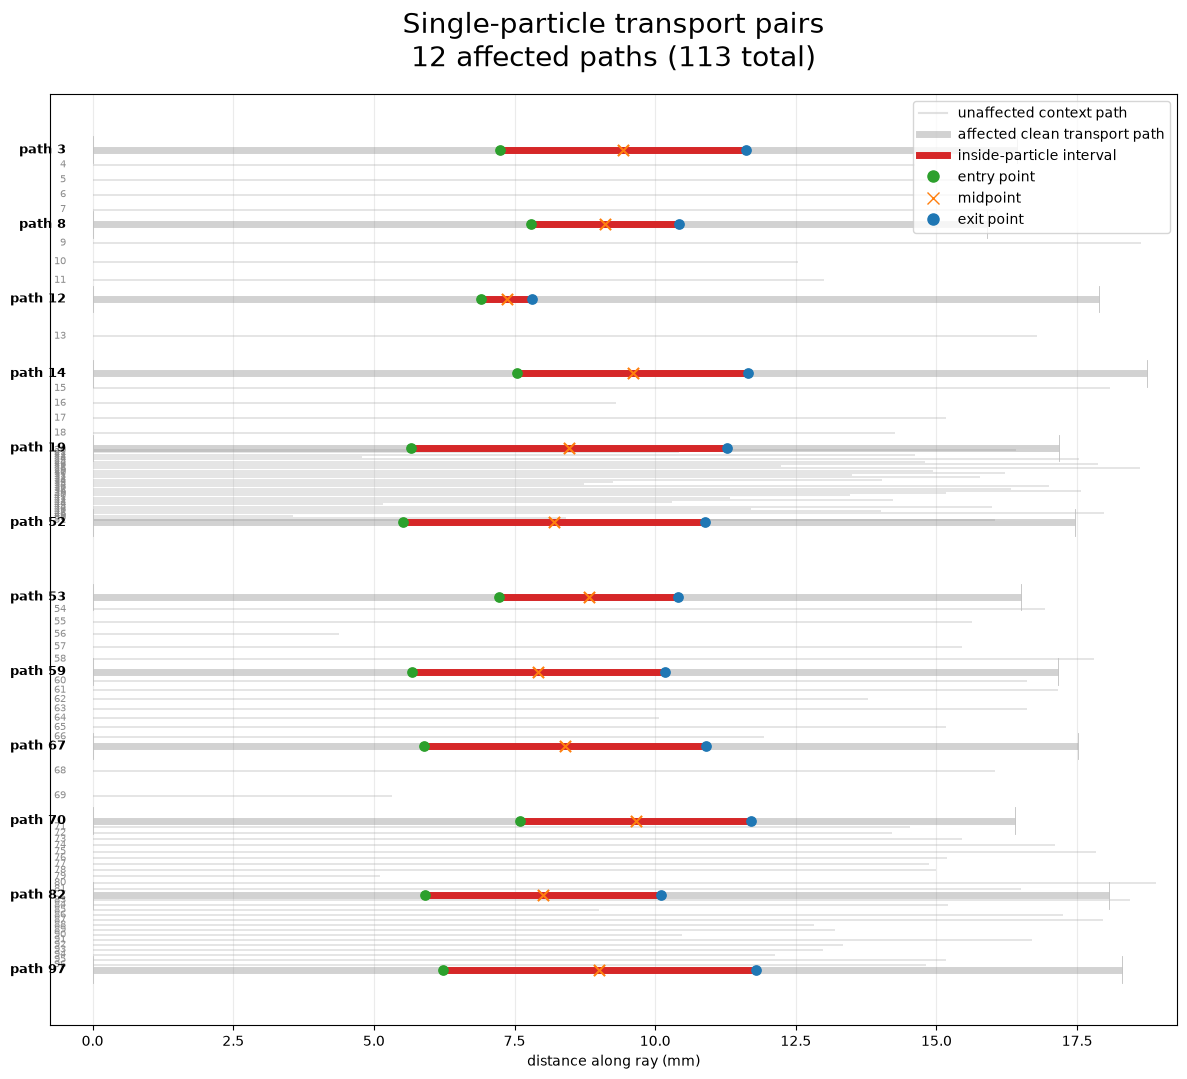

In [6]:
pair_result = build_affected_transport_pairs(segments, particles, events=events)
pairs = tuple(pair_result.pairs)

print(
    f"Single-particle transport pairs: {len(pairs)} pair(s) for "
    f"{len(event_path_ids)} particle-hit transport ray(s)."
)
print()

notebook_tools.run_installed_pytest_test(
    m5_validation,
    "test_affected_pair_indices_match_intersection_events",
)

max_pairs_to_draw = 12
fig, ax = plt.subplots(figsize=(12, 0.7 * max_pairs_to_draw + 2.5))
plot_affected_transport_pairs(
    ax,
    segments,
    np.asarray(ray_ids),
    pairs,
    events,
    max_pairs_to_draw=max_pairs_to_draw,
    include_context_paths=True,
    xlabel="distance along ray (mm)",
    title=(
        "Single-particle transport pairs\n"
        f"{min(max_pairs_to_draw, len(pairs))} affected paths ({len(pairs)} total)"
    ),
)
plt.tight_layout()
plt.show()


## Multi-particle case A — lateral (side-by-side)

Two non-overlapping spheres offset along ±x. Most affected transport rays
typically hit only one of them.


Lateral multi-particle intersections: 174 event(s) on 174 segment(s) and 174 transport ray(s); particle indices hit=[0, 1].


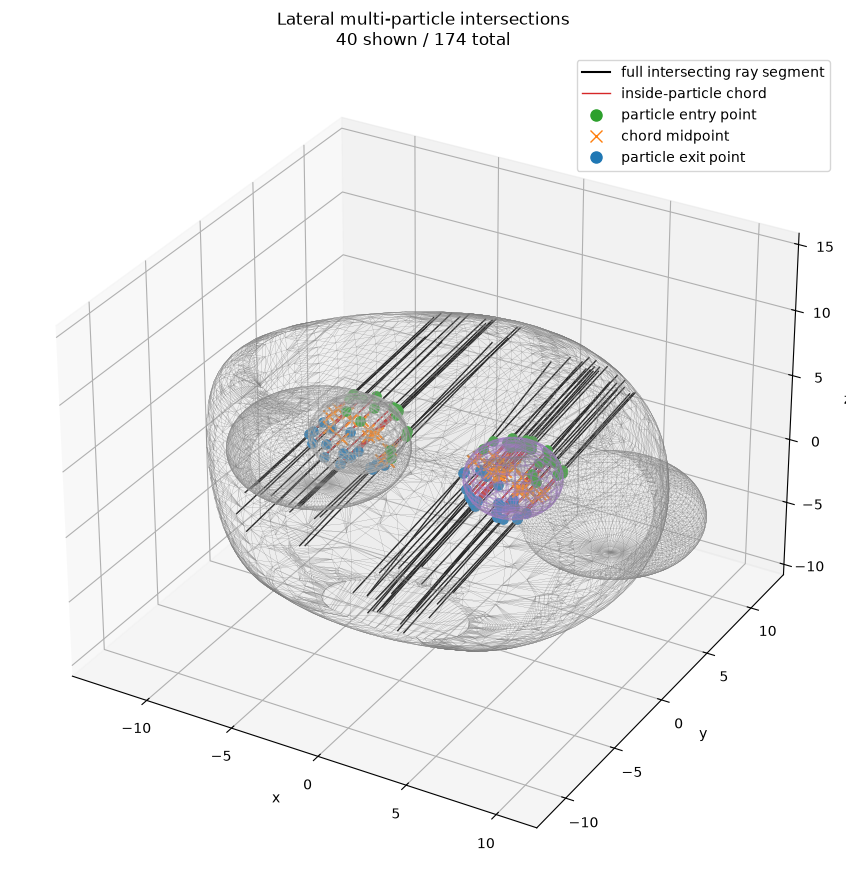

Lateral multi-particle transport pairs: 174 pair(s) for 174 particle-hit transport ray(s).


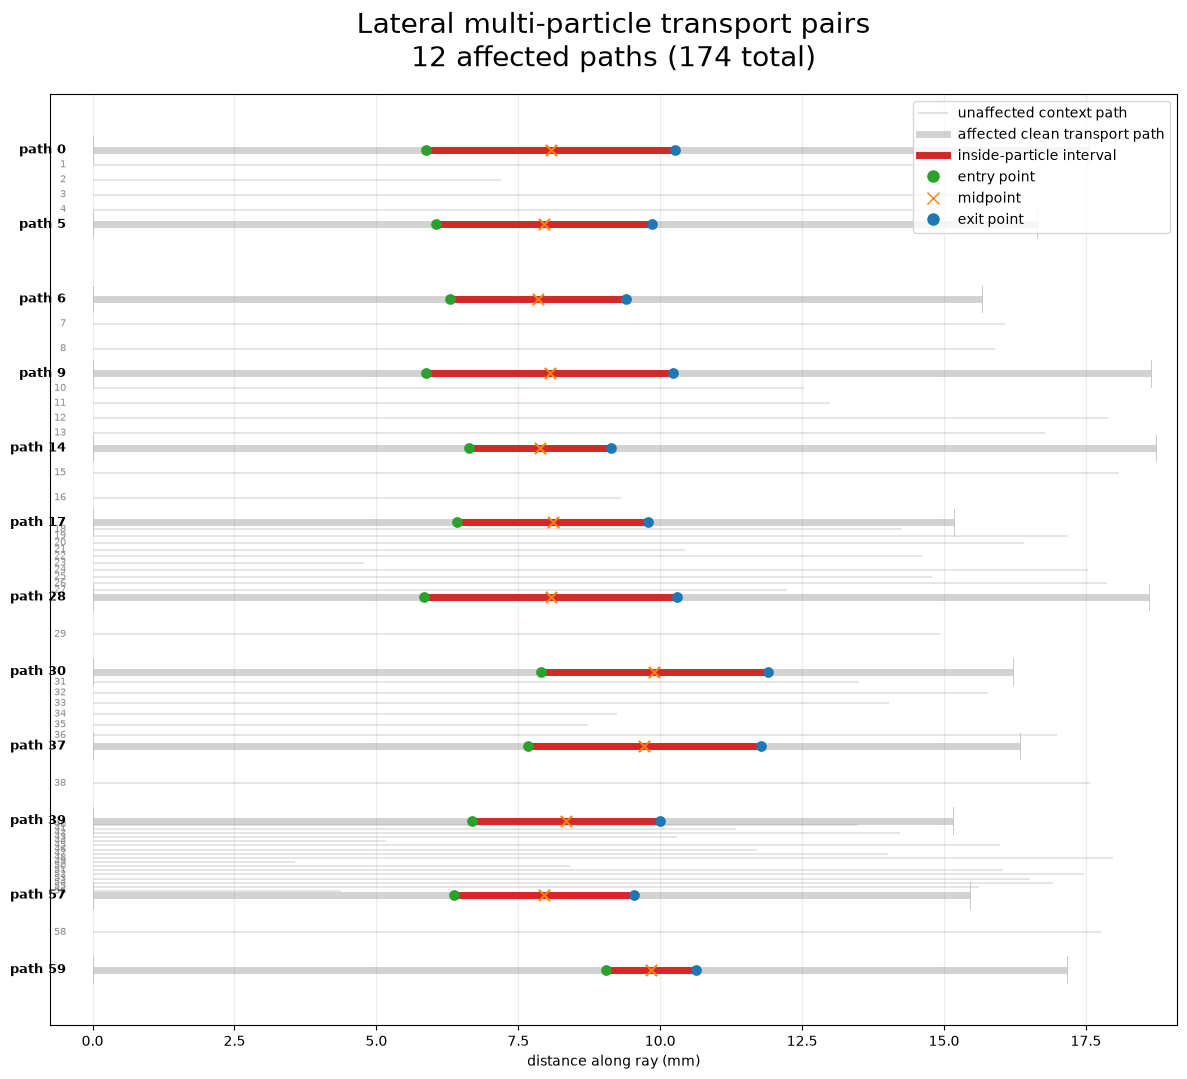

In [7]:
particles = particles_multi_lateral

events_multi = intersect_segments_with_particles(
    segments.starts, segments.ends, particles_multi_lateral
)
events_multi = sorted(
    list(events_multi),
    key=lambda ev: (int(ev.segment_index), float(ev.entry_t), int(ev.particle_index)),
)
if not events_multi:
    raise AssertionError("No lateral multi-particle intersection events were found.")

hit_particle_indices = sorted({int(ev.particle_index) for ev in events_multi})
if hit_particle_indices != [0, 1]:
    raise AssertionError(
        "Expected intersection events on both lateral particles; "
        f"got particle_index set {hit_particle_indices}."
    )

event_segment_indices_multi = np.asarray(
    sorted({int(ev.segment_index) for ev in events_multi}), dtype=int
)
event_path_ids_multi = np.asarray(
    sorted({int(ray_ids[s]) for s in event_segment_indices_multi}), dtype=int
)

print(
    f"Lateral multi-particle intersections: {len(events_multi)} event(s) on "
    f"{len(event_segment_indices_multi)} segment(s) and "
    f"{len(event_path_ids_multi)} transport ray(s); "
    f"particle indices hit={hit_particle_indices}."
)

max_events_to_draw = 40
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection="3d")
plot_particle_intersections_in_mesh(
    ax,
    surface_mesh,
    particles_multi_lateral,
    segments,
    events_multi,
    max_events_to_draw=max_events_to_draw,
    particle_colors=("darkgrey", "tab:purple"),
    chord_linewidth=1.0,
    full_segment_color="black",
    full_segment_linewidth=1.0,
    title=(
        "Lateral multi-particle intersections\n"
        f"{min(max_events_to_draw, len(events_multi))} shown / {len(events_multi)} total"
    ),
)
plt.tight_layout()
plt.show()

pair_result_multi = build_affected_transport_pairs(
    segments, particles_multi_lateral, events=events_multi
)
pairs_multi = tuple(pair_result_multi.pairs)
print(
    f"Lateral multi-particle transport pairs: {len(pairs_multi)} pair(s) for "
    f"{len(event_path_ids_multi)} particle-hit transport ray(s)."
)

max_pairs_to_draw = 12
fig, ax = plt.subplots(figsize=(12, 0.7 * max_pairs_to_draw + 2.5))
plot_affected_transport_pairs(
    ax,
    segments,
    np.asarray(ray_ids),
    pairs_multi,
    events_multi,
    max_pairs_to_draw=max_pairs_to_draw,
    include_context_paths=True,
    xlabel="distance along ray (mm)",
    title=(
        "Lateral multi-particle transport pairs\n"
        f"{min(max_pairs_to_draw, len(pairs_multi))} affected paths ({len(pairs_multi)} total)"
    ),
)
plt.tight_layout()
plt.show()


## Multi-particle case B — in-line (some rays hit both)

Two non-overlapping spheres along the illumination axis through the centroid.
Some transport rays encounter both spheres in sequence.

**Important:** a dual-hit ray still yields **one** `AffectedTransportPair`.
The track plot shows **two** red particle intervals on that **same** path —
both chords live in `pair.particle_events` / `pair.dirty_intervals`, with
intensity continuing through the first inclusion into the second.


In-line multi-particle intersections: 163 event(s) on 94 segment(s) and 94 transport ray(s); dual-hit rays=69 (examples [3, 14, 19, 52, 59]).


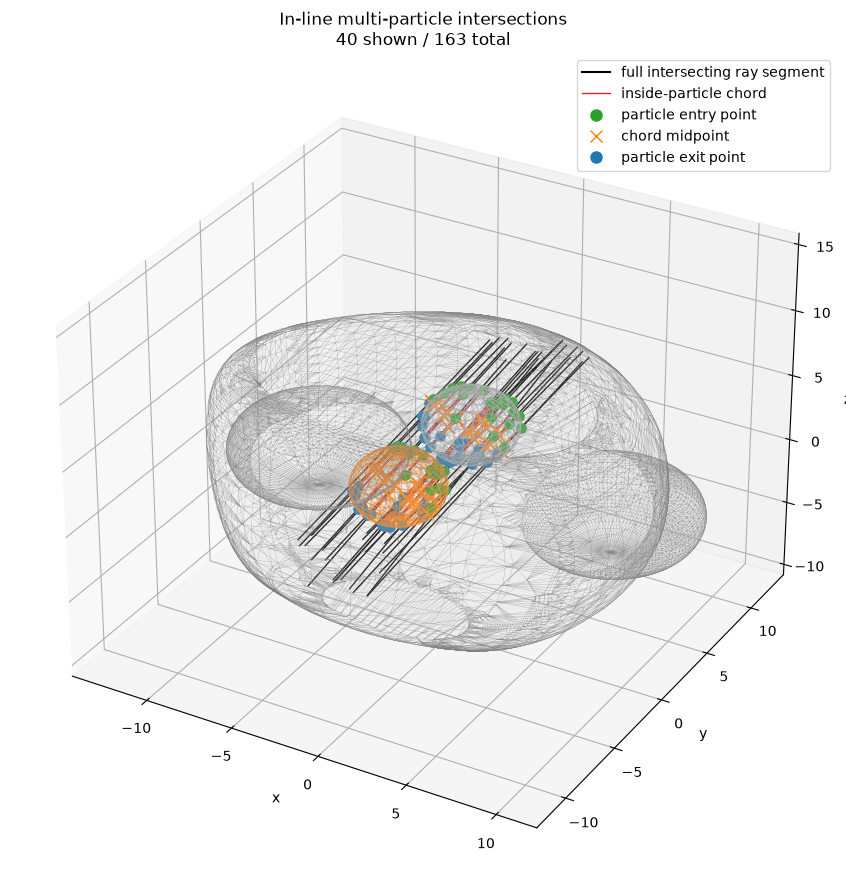

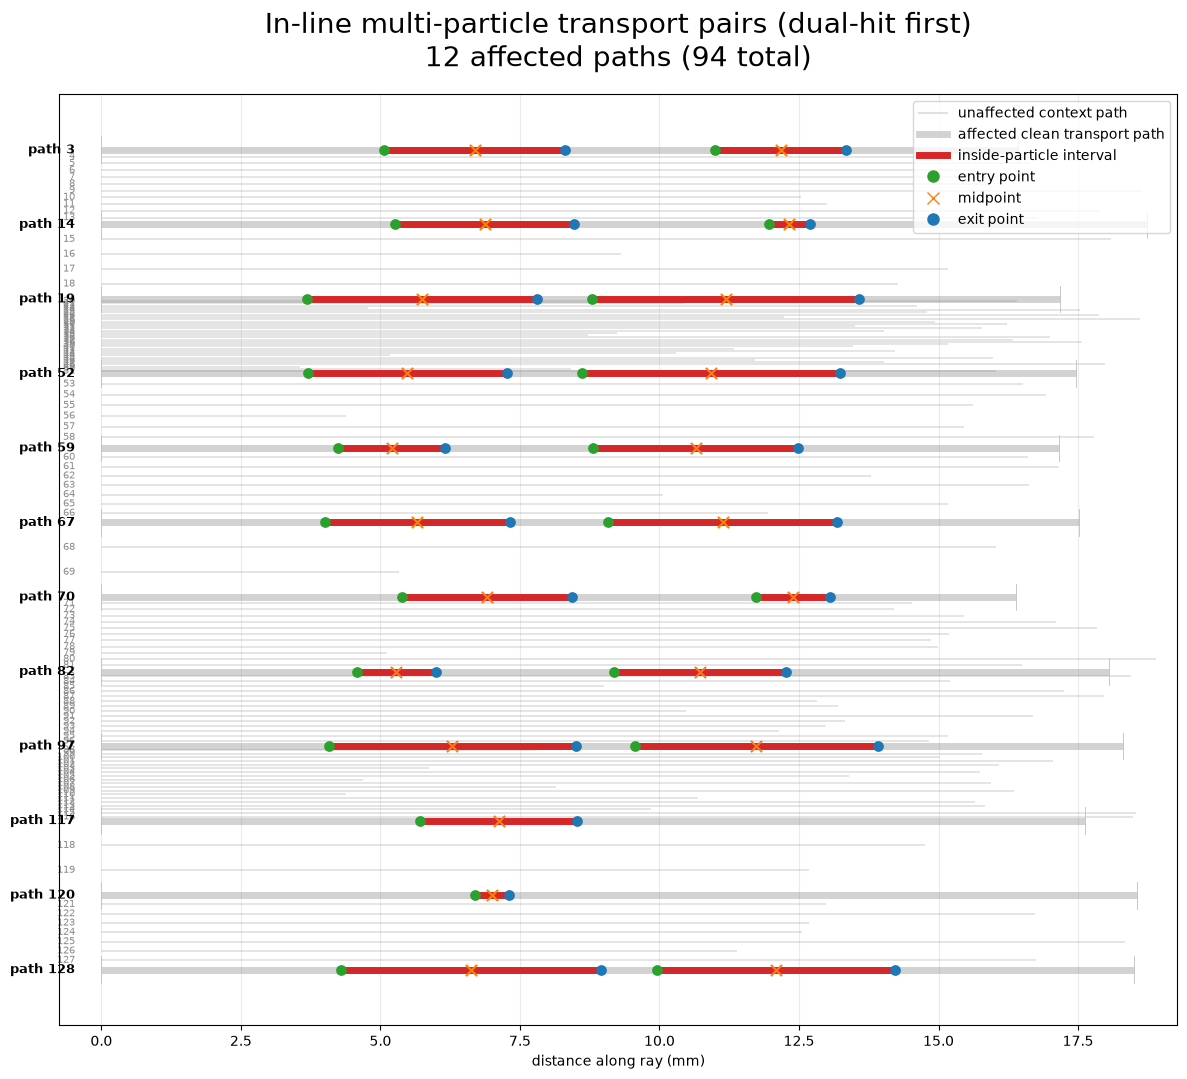

In [8]:
particles = particles_multi_inline

events_inline = intersect_segments_with_particles(
    segments.starts, segments.ends, particles_multi_inline
)
events_inline = sorted(
    list(events_inline),
    key=lambda ev: (int(ev.segment_index), float(ev.entry_t), int(ev.particle_index)),
)
if not events_inline:
    raise AssertionError("No in-line multi-particle intersection events were found.")

hit_particle_indices_inline = sorted({int(ev.particle_index) for ev in events_inline})
if hit_particle_indices_inline != [0, 1]:
    raise AssertionError(
        "Expected intersection events on both in-line particles; "
        f"got particle_index set {hit_particle_indices_inline}."
    )

path_to_particles = {}
for ev in events_inline:
    path_id = int(ray_ids[int(ev.segment_index)])
    path_to_particles.setdefault(path_id, set()).add(int(ev.particle_index))

dual_hit_path_ids = sorted(
    path_id for path_id, idxs in path_to_particles.items() if idxs >= {0, 1}
)
if not dual_hit_path_ids:
    raise AssertionError(
        "In-line placement produced no transport ray that hits both spheres."
    )

event_segment_indices_inline = np.asarray(
    sorted({int(ev.segment_index) for ev in events_inline}), dtype=int
)
event_path_ids_inline = np.asarray(
    sorted({int(ray_ids[s]) for s in event_segment_indices_inline}), dtype=int
)

print(
    f"In-line multi-particle intersections: {len(events_inline)} event(s) on "
    f"{len(event_segment_indices_inline)} segment(s) and "
    f"{len(event_path_ids_inline)} transport ray(s); "
    f"dual-hit rays={len(dual_hit_path_ids)} (examples {dual_hit_path_ids[:5]})."
)

max_events_to_draw = 40
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection="3d")
plot_particle_intersections_in_mesh(
    ax,
    surface_mesh,
    particles_multi_inline,
    segments,
    events_inline,
    max_events_to_draw=max_events_to_draw,
    particle_colors=("darkgrey", "tab:orange"),
    chord_linewidth=1.0,
    full_segment_color="black",
    full_segment_linewidth=1.0,
    title=(
        "In-line multi-particle intersections\n"
        f"{min(max_events_to_draw, len(events_inline))} shown / {len(events_inline)} total"
    ),
)
plt.tight_layout()
plt.show()

pair_result_inline = build_affected_transport_pairs(
    segments, particles_multi_inline, events=events_inline
)
pairs_inline = tuple(pair_result_inline.pairs)
dual_set = set(dual_hit_path_ids)
pairs_inline_ordered = tuple(
    sorted(
        pairs_inline,
        key=lambda pair: (0 if int(pair.path_id) in dual_set else 1, int(pair.path_id)),
    )
)

max_pairs_to_draw = 12
fig, ax = plt.subplots(figsize=(12, 0.7 * max_pairs_to_draw + 2.5))
plot_affected_transport_pairs(
    ax,
    segments,
    np.asarray(ray_ids),
    pairs_inline_ordered,
    events_inline,
    max_pairs_to_draw=max_pairs_to_draw,
    include_context_paths=True,
    xlabel="distance along ray (mm)",
    title=(
        "In-line multi-particle transport pairs (dual-hit first)\n"
        f"{min(max_pairs_to_draw, len(pairs_inline))} affected paths ({len(pairs_inline)} total)"
    ),
)
plt.tight_layout()
plt.show()


# Conclusion Milestone 5B

Intersection events identify affected transport paths; M5B formalizes each such
path as **exactly one** clean/dirty `AffectedTransportPair`. Pairing is by
`path_id`, not by event or particle index.

Validated configurations:

1. single particle,
2. two particles placed laterally (typically one hit → one pair per ray),
3. two particles placed in-line (dual-hit rays → **one** pair with **two**
   sequential particle intervals).

Source correction and diffusion-image consequences are handled in M5C/M5D.
